In [2]:
# Customer Churn Prediction Model

import pandas as pd
import numpy as np
import datetime as dt

In [3]:
df = pd.read_csv('../data/processed/cleaned.csv')
rfm = pd.read_csv('../data/processed/rfm.csv')

In [4]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

In [5]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

In [6]:
import datetime as dt

snapshot_date = df['order_purchase_timestamp'].max()

last_purchase = df.groupby('customer_unique_id')['order_purchase_timestamp'].max()

churn_df = (snapshot_date - last_purchase).dt.days.reset_index()
churn_df.columns = ['customer_unique_id', 'days_since_last_purchase']

churn_df['churn'] = churn_df['days_since_last_purchase'].apply(lambda x: 1 if x > 90 else 0)

In [7]:
rfm_reset = rfm.reset_index()

final_df = rfm_reset.merge(churn_df, on='customer_unique_id')

In [8]:
final_df['avg_order_value'] = final_df['Monetary'] / final_df['Frequency']

In [9]:
final_df.head()

,index,customer_unique_id,Recency,Frequency,Monetary,Segment,R_score,F_score,M_score,RFM_Score,days_since_last_purchase,churn,avg_order_value
0,0,0000366f3b9a7992bf8c76cfdf3221e2,111,1,141.90,Others,4,1,4,414,111,1,141.90
1,1,0000b849f77a49e4a4ce2b2a4ca5be3f,114,1,27.19,Others,4,1,1,411,114,1,27.19
2,2,0000f46a3911fa3c0805444483337064,536,1,86.22,At Risk,1,1,2,112,536,1,86.22
3,3,0000f6ccb0745a6a4b88665a16c9f078,320,1,43.62,At Risk,2,1,1,211,320,1,43.62
4,4,0004aac84e0df4da2b147fca70cf8255,287,1,196.89,At Risk,2,1,4,214,287,1,196.89


In [10]:
X = final_df[['Frequency', 'Monetary', 'avg_order_value']]
y = final_df['churn']

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(class_weight='balanced')
lr.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [14]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [17]:
from xgboost import XGBClassifier
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

xgb = XGBClassifier(
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight
)
xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [18]:
from sklearn.metrics import classification_report

models = {
    "Logistic": lr,
    "RandomForest": rf,
    "XGBoost": xgb
}

for name, model in models.items():
    pred = model.predict(X_test if name != "Logistic" else X_test_scaled)
    print("\n", name)
    print(classification_report(y_test, pred))


 Logistic
              precision    recall  f1-score   support

           0       0.21      0.03      0.06      3675
           1       0.80      0.97      0.88     14742

    accuracy                           0.78     18417
   macro avg       0.51      0.50      0.47     18417
weighted avg       0.68      0.78      0.71     18417


 RandomForest
              precision    recall  f1-score   support

           0       0.47      0.56      0.51      3675
           1       0.89      0.84      0.86     14742

    accuracy                           0.79     18417
   macro avg       0.68      0.70      0.69     18417
weighted avg       0.80      0.79      0.79     18417


 XGBoost
              precision    recall  f1-score   support

           0       0.25      0.59      0.35      3675
           1       0.84      0.56      0.67     14742

    accuracy                           0.56     18417
   macro avg       0.55      0.57      0.51     18417
weighted avg       0.73      0.56     

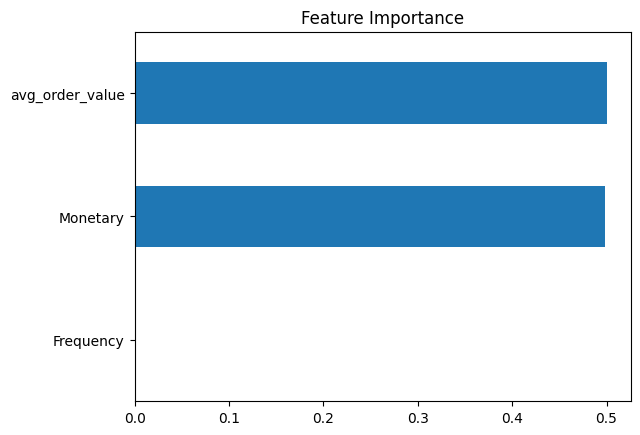

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh', title='Feature Importance')
plt.show()